# Libraries 

In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

In [2]:
# Core
import numpy as np
import pandas as pd
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings("ignore")

# 1. DATA LOADING

In [3]:
# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("amazon_prime_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (2500, 19)


,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,payment_information,renewal_status,usage_frequency,purchase_history,favorite_genres,devices_used,engagement_metrics,feedback_ratings,customer_support_interactions
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,Mastercard,Manual,Regular,Electronics,Documentary,Smart TV,Medium,3.6,3
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,Visa,Manual,Regular,Electronics,Horror,Smartphone,Medium,3.8,7
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,Mastercard,Manual,Regular,Books,Comedy,Smart TV,Low,3.3,8
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,Amex,Auto-renew,Regular,Electronics,Documentary,Smart TV,High,3.3,7
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,Visa,Auto-renew,Frequent,Clothing,Drama,Smart TV,Low,4.3,1


In [4]:
df.dtypes

user_id                            int64
name                              object
email_address                     object
username                          object
date_of_birth                     object
gender                            object
location                          object
membership_start_date             object
membership_end_date               object
subscription_plan                 object
payment_information               object
renewal_status                    object
usage_frequency                   object
purchase_history                  object
favorite_genres                   object
devices_used                      object
engagement_metrics                object
feedback_ratings                 float64
customer_support_interactions      int64
dtype: object

# 2. STANDARDIZE COLUMN NAMES

In [5]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("/", "_", regex=False)
)

# 4. DATE FEATURES

In [6]:
date_cols = ["date_of_birth", "membership_start_date", "membership_end_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

reference_date = df["membership_end_date"].max() + pd.Timedelta(days=1)

df["age"] = ((reference_date - df["date_of_birth"]).dt.days / 365.25).round(1)

# ✅ CREATE THIS FIRST
df["tenure_days"] = (
    df["membership_end_date"] - df["membership_start_date"]
).dt.days

df["days_since_start"] = (
    reference_date - df["membership_start_date"]
).dt.days

df["days_to_expiry"] = (
    df["membership_end_date"] - reference_date
).dt.days

In [7]:
# date_cols = ["date_of_birth", "membership_start_date", "membership_end_date"]

# for col in date_cols:
#     df[col] = pd.to_datetime(df[col], errors="coerce")

# reference_date = df["membership_end_date"].max() + pd.Timedelta(days=1)

# # Age
# df["age"] = ((reference_date - df["date_of_birth"]).dt.days / 365.25).round(1)

# # Tenure
# df["tenure_days"] = (
#     df["membership_end_date"] - df["membership_start_date"]
# ).dt.days
# df["days_to_expiry"] = df["days_to_expiry"].clip(lower=-365)

# # Days since start
# df["days_since_start"] = (
#     reference_date - df["membership_start_date"]
# ).dt.days

# # Days to expiry (FIXED)
# df["days_to_expiry"] = (
#     df["membership_end_date"] - reference_date
# ).dt.days


In [8]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,purchase_history,favorite_genres,devices_used,engagement_metrics,feedback_ratings,customer_support_interactions,age,tenure_days,days_since_start,days_to_expiry
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,Electronics,Documentary,Smart TV,Medium,3.6,3,71.9,365,456,-91
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,Electronics,Horror,Smartphone,Medium,3.8,7,46.8,365,464,-99
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,Books,Comedy,Smart TV,Low,3.3,8,30.4,365,367,-2
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,Electronics,Documentary,Smart TV,High,3.3,7,60.3,365,447,-82
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,Clothing,Drama,Smart TV,Low,4.3,1,63.9,365,426,-61


#  5. ORDINAL ENCODING

In [9]:
usage_map = {
    "Occasional": 1,
    "Regular": 2,
    "Frequent": 3
}

engagement_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}


In [10]:
df["usage_score"] = df["usage_frequency"].map(usage_map).fillna(0)
df["engagement_score_num"] = df["engagement_metrics"].map(engagement_map).fillna(0)

In [11]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,devices_used,engagement_metrics,feedback_ratings,customer_support_interactions,age,tenure_days,days_since_start,days_to_expiry,usage_score,engagement_score_num
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,Smart TV,Medium,3.6,3,71.9,365,456,-91,2,2
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,Smartphone,Medium,3.8,7,46.8,365,464,-99,2,2
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,Smart TV,Low,3.3,8,30.4,365,367,-2,2,1
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,Smart TV,High,3.3,7,60.3,365,447,-82,2,3
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,Smart TV,Low,4.3,1,63.9,365,426,-61,3,1


# 6. FEATURE ENGINEERING

In [12]:
df["support_interaction_rate"] = (
    df["customer_support_interactions"] /
    (df["tenure_days"].replace(0, np.nan))
).fillna(0)

df["feedback_x_support"] = (
    df["feedback_ratings"] * df["customer_support_interactions"]
)

df["behavior_score"] = (
    df["usage_score"] +
    df["engagement_score_num"] +
    df["feedback_ratings"]
)

df["support_intensity"] = (
    df["customer_support_interactions"] /
    (df["tenure_days"] + 1)
)

In [13]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,age,tenure_days,days_since_start,days_to_expiry,usage_score,engagement_score_num,support_interaction_rate,feedback_x_support,behavior_score,support_intensity
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,71.9,365,456,-91,2,2,0.008219,10.8,7.6,0.008197
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,46.8,365,464,-99,2,2,0.019178,26.6,7.8,0.019126
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,30.4,365,367,-2,2,1,0.021918,26.4,6.3,0.021858
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,60.3,365,447,-82,2,3,0.019178,23.1,8.3,0.019126
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,63.9,365,426,-61,3,1,0.002740,4.3,8.3,0.002732


# Engagement Score

In [14]:
# df["engagement_score"] = (
#     0.4 * df["usage_score"] +
#     0.4 * df["engagement_score_num"] +
#     0.2 * df["feedback_ratings"]
# )

In [15]:
df["engagement_score"] = (
    0.4 * (df["usage_score"] / 3) +
    0.4 * (df["engagement_score_num"] / 3) +
    0.2 * (df["feedback_ratings"] / 5)
)

# Plan–Tenure Interaction

In [16]:
plan_map = {
    "Monthly": 1,
    "Annual": 2
}

df["plan_type_num"] = df["subscription_plan"].map(plan_map)

df["plan_tenure_interaction"] = df["plan_type_num"] * df["tenure_days"]

# Feedback Buckets

In [17]:
def feedback_bucket(x):
    if x >= 4.5:
        return "Excellent"
    elif x >= 4.0:
        return "Good"
    elif x >= 3.5:
        return "Average"
    else:
        return "Poor"

df["feedback_bucket"] = df["feedback_ratings"].apply(feedback_bucket)

# Loyalty Score

In [18]:
# df["loyalty_score"] = (
#     0.4 * df["tenure_days"] +
#     0.3 * df["engagement_score"] +
#     0.2 * df["feedback_ratings"] -
#     0.1 * df["customer_support_interactions"]
# )

In [19]:
df["loyalty_score"] = (
    0.4 * (df["tenure_days"] / df["tenure_days"].max()) +
    0.3 * df["engagement_score"] +
    0.2 * (df["feedback_ratings"] / 5) -
    0.1 * (df["customer_support_interactions"] / df["customer_support_interactions"].max())
)

# Risk Segment (BASED ON LOYALTY)

In [20]:
# df["risk_segment"] = pd.cut(
#     df["loyalty_score"],
#     bins=[-np.inf, 280, 300, 315, np.inf],
#     labels=["High Risk", "Medium Risk", "Low Risk", "Very Loyal"]
# )

In [21]:
# df.head()

In [22]:
df["loyalty_segment"] = pd.qcut(
    df["loyalty_score"],
    q=4,
    labels=["Low", "Medium", "high", "Very very Loyal"]
)

# Extra POWER Features

In [23]:
# Expiry urgency
df["expiry_urgency"] = -df["days_to_expiry"]

# Engagement per tenure
df["engagement_per_day"] = df["engagement_score"] / (df["tenure_days"] + 1)

# Support vs engagement ratio
df["support_vs_engagement"] = (
    df["customer_support_interactions"] / (df["engagement_score"] + 1)
)

In [24]:
# Behavior change
# df["engagement_drop"] = df["engagement_score"] / (df["tenure_days"] + 1)

# Expiry urgency (VERY POWERFUL)
df["is_expiring_soon"] = (df["days_to_expiry"] < 30).astype(int)

# Support pressure
df["high_support"] = (df["customer_support_interactions"] > 5).astype(int)

# Plan commitment
df["is_monthly"] = (df["subscription_plan"] == "Monthly").astype(int)

In [25]:


df["low_engagement"] = (df["engagement_score"] < 0.5).astype(int)

df["new_customer"] = (df["tenure_days"] < 60).astype(int)

In [26]:
print(df[[
    "loyalty_score",
    "loyalty_segment",
    "engagement_score",
    "support_intensity"
]].head())

print("\nRisk distribution:")
print(df["loyalty_segment"].value_counts())

   loyalty_score  loyalty_segment  engagement_score  support_intensity
0         0.7172           Medium          0.677333           0.008197
1         0.6876           Medium          0.685333           0.019126
2         0.6116              Low          0.532000           0.021858
3         0.7016           Medium          0.798667           0.019126
4         0.7736  Very very Loyal          0.705333           0.002732

Risk distribution:
loyalty_segment
Medium             627
high               626
Low                625
Very very Loyal    622
Name: count, dtype: int64


# EXPIRY RISK
People close to expiry → more likely to churn

In [27]:
df["expiry_risk"] = np.where(df["days_to_expiry"] < 15, 1, 0)

# PAYMENT RISK

In [28]:
df["payment_risk"] = df["payment_information"].map({
    "Visa": 0,
    "Mastercard": 0,
    "Amex": 1   # assume slightly risky
})

# LOW ENGAGEMENT FLAG

In [29]:
df["low_engagement"] = (df["engagement_score"] < 2).astype(int)

# High Support

In [30]:
df["high_support"] = (df["customer_support_interactions"] > 5).astype(int)

# SHORT TENURE (NEW USERS CHURN MORE)

In [31]:
df["new_customer"] = (df["tenure_days"] < 60).astype(int)

# PLAN RISK

In [32]:
df["monthly_user"] = (df["subscription_plan"] == "Monthly").astype(int)

In [33]:
df["churn_risk_score"] = (
    0.30 * df["expiry_risk"] +
    0.20 * df["low_engagement"] +
    0.15 * df["high_support"] +
    0.15 * df["new_customer"] +
    0.20 * df["monthly_user"]
)

In [34]:
df["engagement_vs_support"] = df["engagement_score"] / (df["customer_support_interactions"] + 1)

In [35]:
# df["risk_segment"] = pd.qcut(
#     df["churn_score"],
#     q=4,
#     labels=["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
# )

In [36]:
df[df["loyalty_segment"] == "Very Loyal"]

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,is_expiring_soon,high_support,is_monthly,low_engagement,new_customer,expiry_risk,payment_risk,monthly_user,churn_risk_score,engagement_vs_support


In [37]:
df[df["loyalty_segment"] == "High Risk"]

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,is_expiring_soon,high_support,is_monthly,low_engagement,new_customer,expiry_risk,payment_risk,monthly_user,churn_risk_score,engagement_vs_support


In [38]:
df

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,is_expiring_soon,high_support,is_monthly,low_engagement,new_customer,expiry_risk,payment_risk,monthly_user,churn_risk_score,engagement_vs_support
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,1,0,0,1,0,1,0,0,0.50,0.169333
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,1,1,1,1,0,1,0,1,0.85,0.085667
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,1,1,1,1,0,1,0,1,0.85,0.059111
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,1,1,1,1,0,1,1,1,0.85,0.099833
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,1,0,0,1,0,1,0,0,0.50,0.352667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,Michael Lopez,williamsroberto@example.org,williamsroberto,1967-08-19,Male,Smithport,2024-01-25,2025-01-24,Annual,...,1,0,0,1,0,1,0,0,0.50,0.287556
2496,2497,Matthew Woodard,lkaiser@example.com,lkaiser,1980-10-23,Male,Ethanport,2024-03-03,2025-03-03,Annual,...,1,0,0,1,0,1,1,0,0.50,0.826667
2497,2498,Morgan Barnes,erikaholland@example.net,erikaholland,1972-03-31,Female,Alexandraborough,2024-02-09,2025-02-08,Annual,...,1,1,0,1,0,1,0,0,0.65,0.081037
2498,2499,Gina Castaneda,reedcourtney@example.net,reedcourtney,1965-08-02,Female,Williammouth,2024-02-18,2025-02-17,Monthly,...,1,1,1,1,0,1,0,1,0.85,0.100333


# Cross Check features Enginerring

# PROFESSIONAL TARGET DESIGN

In [39]:
# Core risk flags
df["low_engagement"] = (df["engagement_score"] < 0.5).astype(int)
df["high_support"] = (df["customer_support_interactions"] > 5).astype(int)
df["new_customer"] = (df["tenure_days"] < 60).astype(int)
df["monthly_user"] = (df["subscription_plan"] == "Monthly").astype(int)
df["expiry_risk"] = (df["days_to_expiry"] < 15).astype(int)

# Advanced behavior signals
df["engagement_drop"] = df["engagement_score"] / (df["tenure_days"] + 1)
df["support_vs_engagement"] = df["customer_support_interactions"] / (df["engagement_score"] + 1)

# NORMALIZE IMPORTANT CONTINUOUS FEATURES

In [40]:
# df["norm_engagement_drop"] = 1 - (df["engagement_drop"] / df["engagement_drop"].max())
# df["norm_support_ratio"] = df["support_vs_engagement"] / df["support_vs_engagement"].max()
# df["norm_feedback"] = 1 - (df["feedback_ratings"] / df["feedback_ratings"].max())

In [41]:
df["norm_engagement_drop"] = 1 - (
    df["engagement_drop"] / (df["engagement_drop"].max() + 1e-6)
)

df["norm_support_ratio"] = (
    df["support_vs_engagement"] / (df["support_vs_engagement"].max() + 1e-6)
)

df["norm_feedback"] = 1 - (
    df["feedback_ratings"] / (df["feedback_ratings"].max() + 1e-6)
)

# Target variable 

In [42]:
import numpy as np

df["churn_probability"] = (
    0.20 * df["expiry_risk"] +                 # strongest signal
    0.15 * df["monthly_user"] +               # short commitment
    0.15 * df["low_engagement"] +             
    0.10 * df["high_support"] +               # friction indicator
    0.10 * df["new_customer"] +               
    0.10 * df["norm_engagement_drop"] +       
    0.10 * df["norm_support_ratio"] +         
    0.10 * df["norm_feedback"] +              
    0.05 * np.random.rand(len(df))            # noise = realism
)

In [43]:
df["churn_risk_percent"] = (df["churn_probability"] * 100).round(2)

In [44]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,payment_risk,monthly_user,churn_risk_score,engagement_vs_support,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0,0,0.50,0.169333,0.001851,0.322914,0.248013,0.28,0.300971,30.10
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,0,1,0.85,0.085667,0.001872,0.314917,0.575949,0.24,0.592988,59.30
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,0,1,0.85,0.059111,0.001454,0.468195,0.724108,0.34,0.635405,63.54
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,1,1,0.85,0.099833,0.002182,0.201626,0.539659,0.34,0.595802,59.58
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0,0,0.50,0.352667,0.001927,0.294925,0.081314,0.14,0.252262,25.23


In [45]:
# df["risk_level"] = pd.cut(
#     df["churn_probability"],
#     bins=[0, 0.3, 0.6, 0.8, 1],
#     labels=["Low", "Medium", "High", "Critical"]
# )

In [46]:
df["risk_level"] = pd.cut(
    df["churn_probability"],
    bins=[0, 0.35, 0.65, 0.85, 1],
    labels=["Low", "Medium", "High", "Critical"]
)

In [47]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,monthly_user,churn_risk_score,engagement_vs_support,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent,risk_level
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0,0.50,0.169333,0.001851,0.322914,0.248013,0.28,0.300971,30.10,Low
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,1,0.85,0.085667,0.001872,0.314917,0.575949,0.24,0.592988,59.30,Medium
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,1,0.85,0.059111,0.001454,0.468195,0.724108,0.34,0.635405,63.54,Medium
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,1,0.85,0.099833,0.002182,0.201626,0.539659,0.34,0.595802,59.58,Medium
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0,0.50,0.352667,0.001927,0.294925,0.081314,0.14,0.252262,25.23,Low


# PROFESSIONAL TARGET DESIGN

In [48]:
# df["norm_engagement"] = 1 - (df["engagement_score"] / df["engagement_score"].max())
# df["norm_tenure"] = 1 - (df["tenure_days"] / df["tenure_days"].max())
# df["norm_support"] = df["customer_support_interactions"] / df["customer_support_interactions"].max()
# df["norm_expiry"] = (df["days_to_expiry"] < 15).astype(int)
# df["norm_plan"] = (df["subscription_plan"] == "Monthly").astype(int)

# Churn Risk Score

In [49]:
# df["churn_score"] = (
#     0.30 * df["norm_expiry"] +
#     0.25 * df["norm_engagement"] +
#     0.20 * df["norm_support"] +
#     0.15 * df["norm_tenure"] +
#     0.10 * df["norm_plan"] +
#     0.15 * np.random.rand(len(df))   # 🔥 ADD THIS
# )

In [50]:
# df["churn_score"].describe()

In [51]:
threshold = df["churn_probability"].quantile(0.65)

df["churn"] = (df["churn_probability"] > threshold).astype(int)

In [52]:
# y = df['Churn']

In [53]:
# threshold = df["churn_score"].quantile(0.65)

# df["churn"] = (df["churn_score"] > threshold).astype(int)

In [54]:
print(df["churn"].value_counts(normalize=True))

churn
0    0.65
1    0.35
Name: proportion, dtype: float64


In [55]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df["churn"]),
    y=df["churn"]
)

print(dict(zip(np.unique(df["churn"]), class_weights)))

{0: 0.7692307692307693, 1: 1.4285714285714286}


# Target variable 

In [56]:
# import numpy as np

# # Create hidden risk score (DO NOT include all features used later)
# df["hidden_risk"] = (
#     0.25 * (df["tenure_days"] < 60).astype(int) +
#     0.20 * (df["feedback_ratings"] < 3).astype(int) +
#     0.20 * (df["usage_score"] < 2).astype(int) +
#     0.15 * (df["support_intensity"] > 0.1).astype(int) +
#     0.10 * (df["payment_risk"]) +
#     0.10 * np.random.rand(len(df))  # 🔥 noise (VERY IMPORTANT)
# )

# # Convert to probability
# df["churn_prob"] = df["hidden_risk"]

# # Final target (threshold)
# df["churn"] = (df["churn_prob"] > 0.5).astype(int)

In [57]:
import numpy as np

# # Risk score with noise
# df["churn_score"] = (
#     0.30 * df["norm_expiry"] +
#     0.25 * df["norm_engagement"] +
#     0.20 * df["norm_support"] +
#     0.15 * df["norm_tenure"] +
#     0.10 * df["norm_plan"] +
#     0.15 * np.random.rand(len(df))
# )

# # Dynamic threshold
# threshold = df["churn_score"].quantile(0.65)

# # Final target
# df["churn"] = (df["churn_score"] > threshold).astype(int)

# Check
print(df["churn"].value_counts())

churn
0    1625
1     875
Name: count, dtype: int64


churn
0    1625
1     875
Name: count, dtype: int64
churn
0    0.65
1    0.35
Name: proportion, dtype: float64


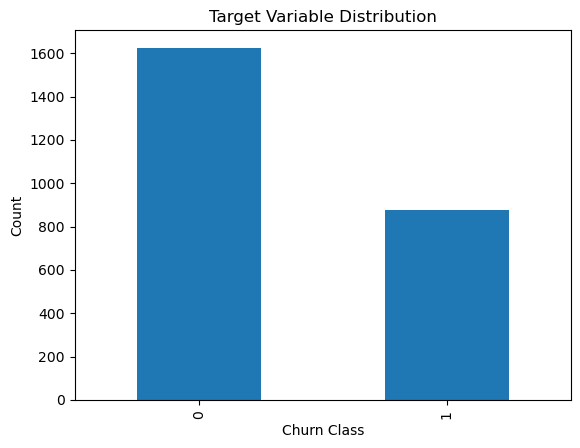

In [58]:
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True))

import matplotlib.pyplot as plt

df["churn"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Churn Class")
plt.ylabel("Count")
plt.show()

Balanaced

In [59]:
# df["churn"] = (
#     (df["days_to_expiry"] < 15) &   # stricter
#     (df["engagement_score"] < 1.5) &
#     (df["customer_support_interactions"] > 8)
# ).astype(int)

Weight

In [60]:
# df["churn_score"] = (
#     0.4 * (df["days_to_expiry"] < 20).astype(int) +
#     0.3 * (df["engagement_score"] < 2).astype(int) +
#     0.2 * (df["customer_support_interactions"] > 6).astype(int) +
#     0.1 * (df["subscription_plan"] == "Monthly").astype(int)
# )

# df["churn"] = (df["churn_score"] >= 0.5).astype(int)

In [61]:
# threshold = df["churn_score"].quantile(0.65)

# df["churn"] = (df["churn_score"] >= threshold).astype(int)

Previous

In [62]:
# df["churn"] = (
#     (df["days_to_expiry"] < 30) |
#     (df["engagement_score"] < 2) |
#     (df["customer_support_interactions"] > 6) |
#     (df["subscription_plan"] == "Monthly")
# ).astype(int)

In [63]:
print(df["churn"].value_counts())

# MUST HAVE BOTH CLASSES
assert df["churn"].nunique() == 2

churn
0    1625
1     875
Name: count, dtype: int64


In [64]:
print(df["churn"].value_counts())

churn
0    1625
1     875
Name: count, dtype: int64


# 7. DROP LEAKAGE / ID COLS

In [65]:
# drop_cols = [
#     "user_id",
#     "name",
#     "email_address",
#     "username",
#     "renewal_status",
#     "date_of_birth",
#     "membership_start_date",
#     "membership_end_date"
# ]

# X = df.drop(
#     columns=drop_cols + [
#         "churn",
#         "risk_segment",
#         "churn_prob",
#         "hidden_risk",
#         "churn_score"
#     ],
#     errors="ignore"
# )

# y = df["churn"]

In [66]:
# REMOVE churn
y = df["churn_probability"]   # regression

In [67]:
# leak_cols = ['churn_probability','risk_segment','churn_risk_percent','risk_level']
# print("Leakage check:", [c for c in leak_cols if c in X.columns])

In [68]:
# =============================
# NORMALIZATION (SAFE)
# =============================
df["norm_engagement_drop"] = 1 - (
    df["engagement_drop"] / (df["engagement_drop"].max() + 1e-6)
)

df["norm_support_ratio"] = (
    df["support_vs_engagement"] / (df["support_vs_engagement"].max() + 1e-6)
)

df["norm_feedback"] = 1 - (
    df["feedback_ratings"] / (df["feedback_ratings"].max() + 1e-6)
)

# =============================
# TARGET CREATION
# =============================
threshold = df["churn_probability"].quantile(0.65)
df["churn"] = (df["churn_probability"] > threshold).astype(int)

# =============================
# TARGET CHECK
# =============================
print(df["churn"].value_counts(normalize=True))

# =============================
# SPLIT FEATURES / TARGET
# =============================
y = df["churn"]

drop_cols = [
    "user_id","name","email_address","username",
    "renewal_status","date_of_birth",
    "membership_start_date","membership_end_date",
    "risk_segment","churn_probability",
    "churn_risk_percent","risk_level"
]

X = df.drop(columns=drop_cols + ["churn"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)

churn
0    0.65
1    0.35
Name: proportion, dtype: float64
X shape: (2500, 44)
y shape: (2500,)


In [69]:
# drop_cols = [
#     "user_id",
#     "name",
#     "email_address",
#     "username",
#     "renewal_status",
#     "date_of_birth",
#     "membership_start_date",
#     "membership_end_date",
    
#     # target/helper cols
#     "churn",
#     "risk_segment",          # business label, not model input
#     "churn_probability",     # derived helper
#     "churn_risk_percent",    # derived helper
#     "risk_level",            # derived helper
# ]

# X = df.drop(columns=drop_cols)
# y = df["churn"]

# print("X shape:", X.shape)
# print("y shape:", y.shape)
# print(X.columns.tolist())

#  8. COLUMN TYPES

In [70]:
# categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
# numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [71]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['gender', 'location', 'subscription_plan', 'payment_information', 'usage_frequency', 'purchase_history', 'favorite_genres', 'devices_used', 'engagement_metrics', 'feedback_bucket', 'loyalty_segment']
Numeric: ['feedback_ratings', 'customer_support_interactions', 'age', 'tenure_days', 'days_since_start', 'days_to_expiry', 'usage_score', 'engagement_score_num', 'support_interaction_rate', 'feedback_x_support', 'behavior_score', 'support_intensity', 'engagement_score', 'plan_type_num', 'plan_tenure_interaction', 'loyalty_score', 'expiry_urgency', 'engagement_per_day', 'support_vs_engagement', 'is_expiring_soon', 'high_support', 'is_monthly', 'low_engagement', 'new_customer', 'expiry_risk', 'payment_risk', 'monthly_user', 'churn_risk_score', 'engagement_vs_support', 'engagement_drop', 'norm_engagement_drop', 'norm_support_ratio', 'norm_feedback']


In [72]:
print("Columns in X:", list(X.columns))
print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

Columns in X: ['gender', 'location', 'subscription_plan', 'payment_information', 'usage_frequency', 'purchase_history', 'favorite_genres', 'devices_used', 'engagement_metrics', 'feedback_ratings', 'customer_support_interactions', 'age', 'tenure_days', 'days_since_start', 'days_to_expiry', 'usage_score', 'engagement_score_num', 'support_interaction_rate', 'feedback_x_support', 'behavior_score', 'support_intensity', 'engagement_score', 'plan_type_num', 'plan_tenure_interaction', 'feedback_bucket', 'loyalty_score', 'loyalty_segment', 'expiry_urgency', 'engagement_per_day', 'support_vs_engagement', 'is_expiring_soon', 'high_support', 'is_monthly', 'low_engagement', 'new_customer', 'expiry_risk', 'payment_risk', 'monthly_user', 'churn_risk_score', 'engagement_vs_support', 'engagement_drop', 'norm_engagement_drop', 'norm_support_ratio', 'norm_feedback']
Numeric cols: ['feedback_ratings', 'customer_support_interactions', 'age', 'tenure_days', 'days_since_start', 'days_to_expiry', 'usage_score

# 9. PREPROCESSING

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [74]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,churn_risk_score,engagement_vs_support,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent,risk_level,churn
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0.50,0.169333,0.001851,0.322914,0.248013,0.28,0.300971,30.10,Low,0
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,0.85,0.085667,0.001872,0.314917,0.575949,0.24,0.592988,59.30,Medium,1
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,0.85,0.059111,0.001454,0.468195,0.724108,0.34,0.635405,63.54,Medium,1
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,0.85,0.099833,0.002182,0.201626,0.539659,0.34,0.595802,59.58,Medium,1
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0.50,0.352667,0.001927,0.294925,0.081314,0.14,0.252262,25.23,Low,0


# 10. TRAIN / TEST SPLIT

# Regression

In [75]:
from sklearn.model_selection import train_test_split

# TARGET (REAL ML)
y = df["churn_probability"]

# FEATURES
X = df.drop(columns=[
    "user_id","name","email_address","username",
    "renewal_status","date_of_birth",
    "membership_start_date","membership_end_date",
    "risk_segment","churn_probability",
    "churn_risk_percent","risk_level"
], errors="ignore")

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2000, 45) Test: (500, 45)


# Classification 

In [76]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.20,
#     stratify=y,
#     random_state=42
# )

# print(y_train.value_counts(normalize=True))
# print(y_test.value_counts(normalize=True))

# 11. MODELS

# For classification churn (0,1)

In [77]:
# import time
# import pandas as pd

# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
# from sklearn.model_selection import StratifiedKFold, cross_validate
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     roc_auc_score, confusion_matrix
# )

# models = {
#     "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
#     "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42),
#     "Random Forest": RandomForestClassifier(
#         n_estimators=300, class_weight="balanced", max_depth=8, random_state=42, n_jobs=-1
#     ),
#     "Extra Trees": ExtraTreesClassifier(
#         n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
#     ),
#     "Gradient Boosting": GradientBoostingClassifier(random_state=42)
# }

# try:
#     from xgboost import XGBClassifier
#     models["XGBoost"] = XGBClassifier(
#         n_estimators=400,
#         learning_rate=0.03,
#         max_depth=6,
#         subsample=0.9,
#         colsample_bytree=0.9,
#         scale_pos_weight=1,
#         eval_metric="logloss",
#         random_state=42
#     )
# except Exception as e:
#     print("XGBoost not installed:", e)

# for regression Version (Probability)

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# XGBoost
try:
    from xgboost import XGBRegressor
    models["XGBoost"] = XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
except:
    print("XGBoost not installed")

# 12. Compare all models with CV + test metrics + TP/FP/TN/FN

In [79]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# results = []
# trained_models = {}

# for name, model in models.items():
#     pipe = Pipeline([
#         ("preprocessor", preprocessor),
#         ("model", model)
#     ])

#     start_time = time.time()

#     cv_results = cross_validate(
#         pipe,
#         X_train,
#         y_train,
#         cv=cv,
#         scoring={
#             "roc_auc": "roc_auc",
#             "accuracy": "accuracy",
#             "f1": "f1"
#         },
#         return_train_score=True,
#         n_jobs=-1
#     )

#     pipe.fit(X_train, y_train)
#     trained_models[name] = pipe

#     y_pred = pipe.predict(X_test)
#     y_proba = pipe.predict_proba(X_test)[:, 1]

#     tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

#     end_time = time.time()

#     results.append({
#         "Model": name,
#         "CV_ROC_AUC": cv_results["test_roc_auc"].mean(),
#         "CV_Accuracy": cv_results["test_accuracy"].mean(),
#         "CV_F1": cv_results["test_f1"].mean(),
#         "Train_Accuracy": cv_results["train_accuracy"].mean(),

#         "Test_ROC_AUC": roc_auc_score(y_test, y_proba),
#         "Accuracy": accuracy_score(y_test, y_pred),
#         "Precision": precision_score(y_test, y_pred),
#         "Recall": recall_score(y_test, y_pred),
#         "F1": f1_score(y_test, y_pred),

#         "TP": tp,
#         "FP": fp,
#         "TN": tn,
#         "FN": fn,

#         "Time_Seconds": round(end_time - start_time, 2)
#     })

# results_df = pd.DataFrame(results).sort_values(by="Test_ROC_AUC", ascending=False)
# results_df.head()

# regression 

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import time

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()

    # Cross-validation
    cv_rmse = -cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    cv_r2 = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    ).mean()

    # Train
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    # Predict
    y_pred = pipe.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    end_time = time.time()

    results.append({
        "Model": name,
        "CV_RMSE": cv_rmse,
        "CV_R2": cv_r2,
        "Test_RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Time": round(end_time - start_time, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="Test_RMSE")

results_df

,Model,CV_RMSE,CV_R2,Test_RMSE,MAE,R2,Time
4,Gradient Boosting,0.015142,0.984462,0.016261,0.014066,0.980620,12.23
5,XGBoost,0.015880,0.982906,0.016490,0.014023,0.980069,20.32
2,Random Forest,0.015874,0.982912,0.016592,0.014172,0.979822,127.41
3,Extra Trees,0.016144,0.982338,0.016632,0.014098,0.979724,61.83
0,Linear Regression,0.018081,0.977830,0.017775,0.014875,0.976843,12.73
1,Decision Tree,0.018001,0.978031,0.018076,0.015161,0.976050,0.91


# generalization Key Matrix

In [ ]:
results = []
trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()

    # CV
    cv_rmse = -cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    ).mean()

    cv_r2 = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    ).mean()

    # Train model
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    # Train prediction
    train_pred = pipe.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    # Test prediction
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Overfit gap
    overfit_gap = train_rmse - cv_rmse

    end_time = time.time()

    # ✅ IMPORTANT: inside loop
    results.append({
        "Model": name,
        "CV_RMSE": cv_rmse,
        "CV_R2": cv_r2,
        "Train_RMSE": train_rmse,
        "Test_RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Overfit_Gap": overfit_gap,
        "Time": round(end_time - start_time, 2)
    })

# Create dataframe AFTER loop
results_df = pd.DataFrame(results)

In [142]:
results_df

,Model,CV_RMSE,CV_R2,Train_RMSE,Test_RMSE,MAE,R2,Overfit_Gap,Time,Score
4,Gradient Boosting,0.015142,0.984462,0.013261,0.016261,0.014066,0.980620,-0.001881,14.37,0.482956
2,Random Forest,0.015874,0.982912,0.011803,0.016592,0.014172,0.979822,-0.004071,63.97,0.481728
3,Extra Trees,0.016144,0.982338,0.011984,0.016632,0.014098,0.979724,-0.004160,49.31,0.481498
5,XGBoost,0.015880,0.982906,0.008351,0.016490,0.014023,0.980069,-0.007529,11.63,0.481135
1,Decision Tree,0.018001,0.978031,0.015140,0.018076,0.015161,0.976050,-0.002861,1.88,0.479009
0,Linear Regression,0.018081,0.977830,0.003840,0.017775,0.014875,0.976843,-0.014241,2.75,0.476982


In [82]:
results_df["Score"] = (
    -0.5 * results_df["Test_RMSE"] +
    0.3 * results_df["CV_R2"] +
    0.2 * results_df["R2"] -
    0.2 * abs(results_df["Overfit_Gap"])
)

results_df = results_df.sort_values(by="Score", ascending=False)

In [ ]:
results_df

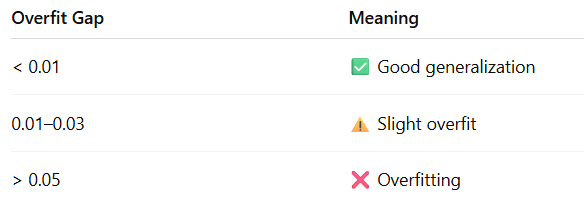

Learning rates

In [83]:
param_grid = {
    "model__learning_rate": [0.01, 0.03, 0.1],
    "model__max_depth": [4, 6, 8],
    "model__n_estimators": [200, 400]
}

# Train vs CV vs Test

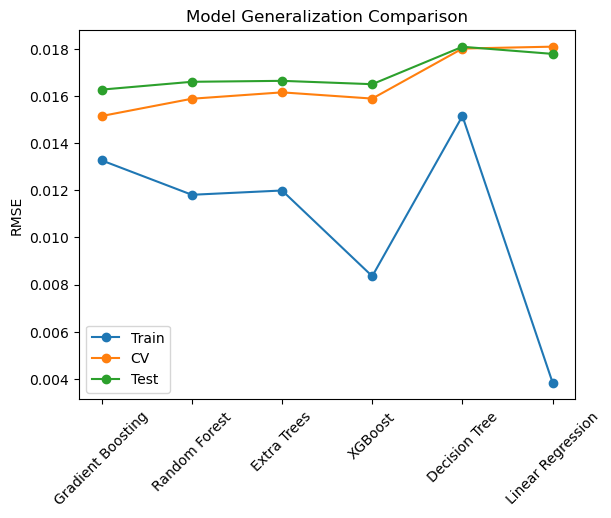

In [84]:
plt.figure()

plt.plot(results_df["Model"], results_df["Train_RMSE"], marker='o', label="Train")
plt.plot(results_df["Model"], results_df["CV_RMSE"], marker='o', label="CV")
plt.plot(results_df["Model"], results_df["Test_RMSE"], marker='o', label="Test")

plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Generalization Comparison")
plt.legend()

plt.show()

# Overfitting Visualization

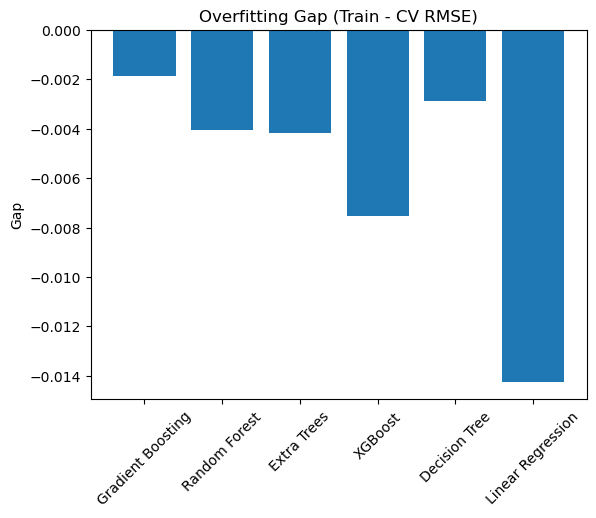

In [85]:
plt.figure()

plt.bar(results_df["Model"], results_df["Overfit_Gap"])

plt.axhline(0)
plt.xticks(rotation=45)
plt.title("Overfitting Gap (Train - CV RMSE)")
plt.ylabel("Gap")

plt.show()

# Model Ranking

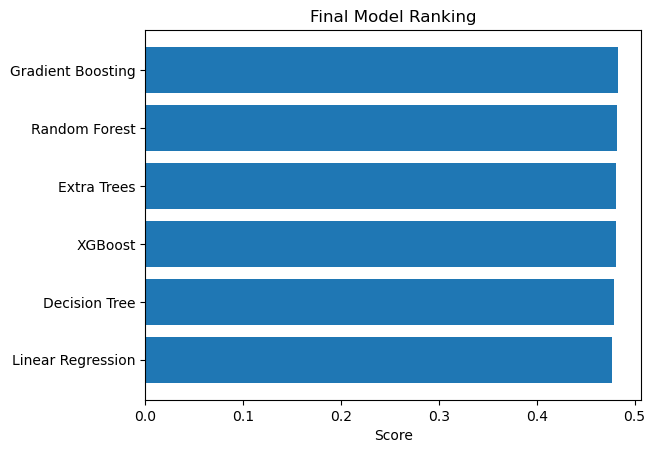

In [86]:
plt.figure()

plt.barh(results_df["Model"], results_df["Score"])

plt.xlabel("Score")
plt.title("Final Model Ranking")
plt.gca().invert_yaxis()

plt.show()

# Error Distribution

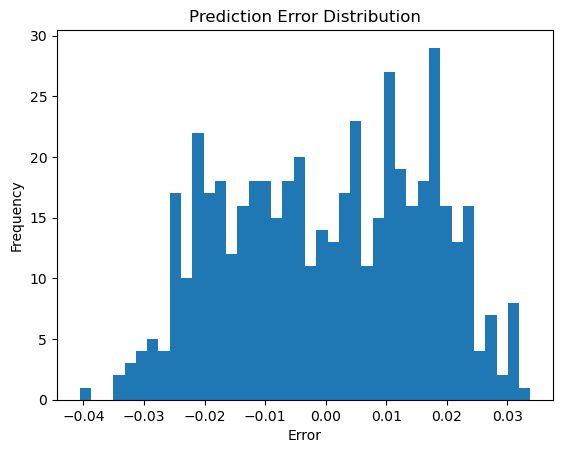

In [87]:
best_model = trained_models[results_df.iloc[0]["Model"]]

y_pred = best_model.predict(X_test)
errors = y_test - y_pred

plt.figure()
plt.hist(errors, bins=40)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

# Predicted vs Actual

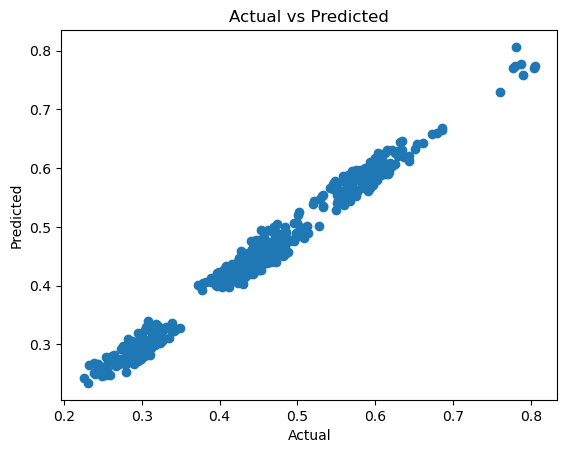

In [88]:
plt.figure()

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

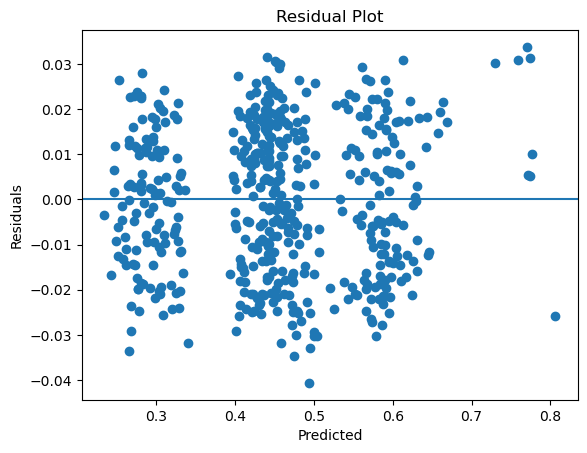

In [89]:
plt.figure()

plt.scatter(y_pred, y_test - y_pred)

plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

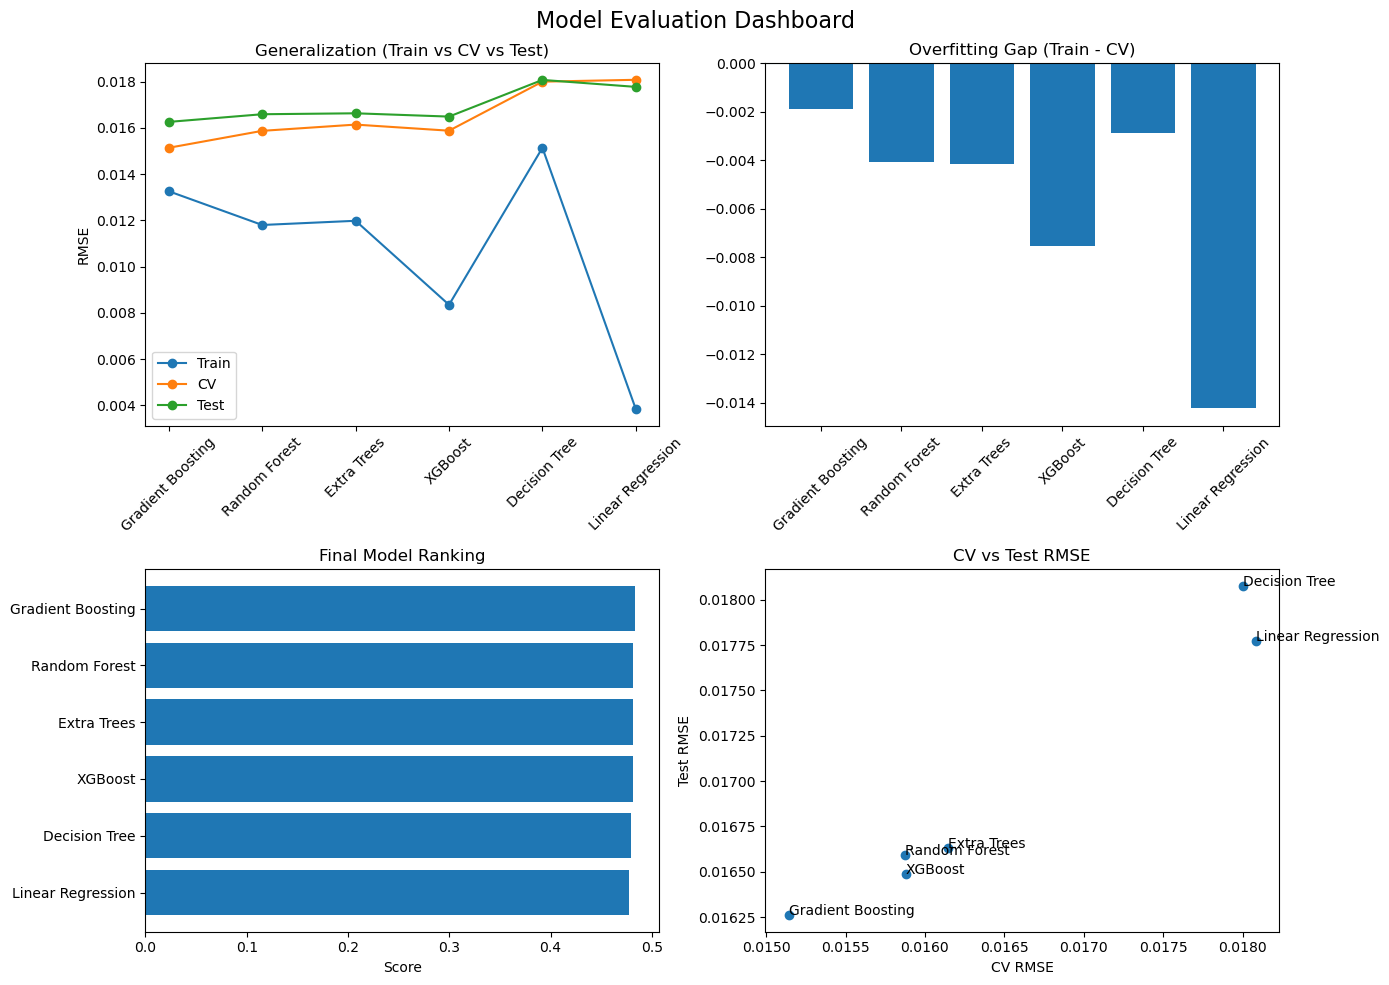

In [90]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------------
# 1. Train vs CV vs Test RMSE
# -------------------------------
axes[0, 0].plot(results_df["Model"], results_df["Train_RMSE"], marker='o', label="Train")
axes[0, 0].plot(results_df["Model"], results_df["CV_RMSE"], marker='o', label="CV")
axes[0, 0].plot(results_df["Model"], results_df["Test_RMSE"], marker='o', label="Test")

axes[0, 0].set_title("Generalization (Train vs CV vs Test)")
axes[0, 0].set_ylabel("RMSE")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()


# -------------------------------
# 2. Overfit Gap
# -------------------------------
axes[0, 1].bar(results_df["Model"], results_df["Overfit_Gap"])
axes[0, 1].axhline(0)

axes[0, 1].set_title("Overfitting Gap (Train - CV)")
axes[0, 1].tick_params(axis='x', rotation=45)


# -------------------------------
# 3. Model Score Ranking
# -------------------------------
axes[1, 0].barh(results_df["Model"], results_df["Score"])
axes[1, 0].invert_yaxis()

axes[1, 0].set_title("Final Model Ranking")
axes[1, 0].set_xlabel("Score")


# -------------------------------
# 4. CV vs Test Scatter (stability)
# -------------------------------
axes[1, 1].scatter(results_df["CV_RMSE"], results_df["Test_RMSE"])

for i, row in results_df.iterrows():
    axes[1, 1].text(row["CV_RMSE"], row["Test_RMSE"], row["Model"])

axes[1, 1].set_title("CV vs Test RMSE")
axes[1, 1].set_xlabel("CV RMSE")
axes[1, 1].set_ylabel("Test RMSE")


# -------------------------------
# Final layout
# -------------------------------
plt.suptitle("Model Evaluation Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

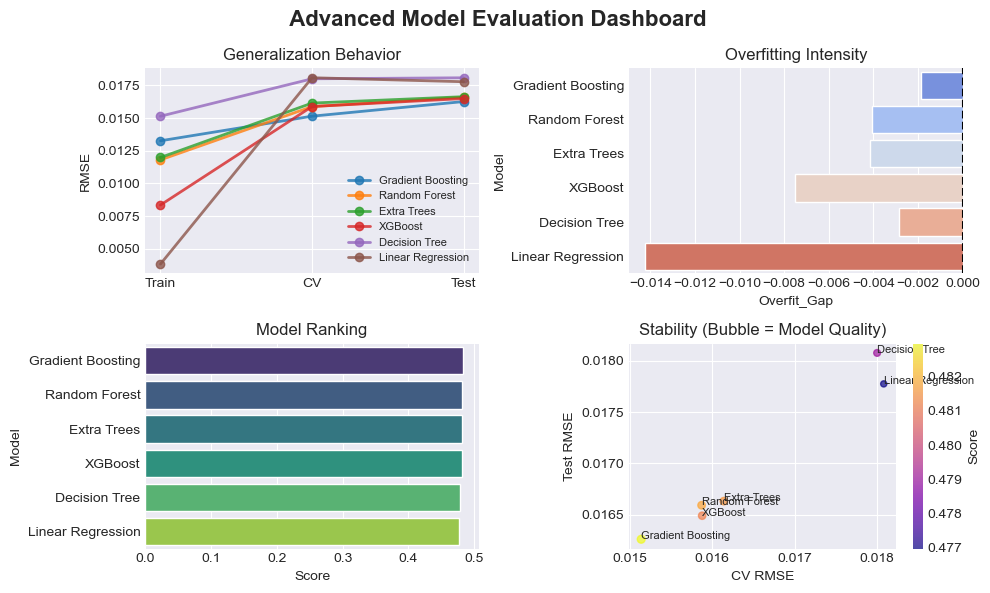

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-darkgrid")

# Color palette
palette = sns.color_palette("viridis", len(results_df))

fig = plt.figure(figsize=(10, 6))

# -------------------------------
# 1. Generalization Curve
# -------------------------------
ax1 = plt.subplot(2, 2, 1)

for i, row in results_df.iterrows():
    ax1.plot(
        ["Train", "CV", "Test"],
        [row["Train_RMSE"], row["CV_RMSE"], row["Test_RMSE"]],
        marker='o',
        linewidth=2,
        alpha=0.8,
        label=row["Model"]
    )

ax1.set_title("Generalization Behavior", fontsize=12)
ax1.set_ylabel("RMSE")
ax1.legend(fontsize=8)


# -------------------------------
# 2. Overfitting Heat Bars
# -------------------------------
ax2 = plt.subplot(2, 2, 2)

sns.barplot(
    x="Overfit_Gap",
    y="Model",
    data=results_df,
    palette="coolwarm",
    ax=ax2
)

ax2.axvline(0, color='black', linestyle='--')
ax2.set_title("Overfitting Intensity")


# -------------------------------
# 3. Ranking with Gradient
# -------------------------------
ax3 = plt.subplot(2, 2, 3)

sns.barplot(
    x="Score",
    y="Model",
    data=results_df,
    palette="viridis",
    ax=ax3
)

ax3.set_title("Model Ranking")


# -------------------------------
# 4. CV vs Test Bubble Plot
# -------------------------------
ax4 = plt.subplot(2, 2, 4)

sizes = (results_df["Score"] - results_df["Score"].min() + 0.01) * 2000

scatter = ax4.scatter(
    results_df["CV_RMSE"],
    results_df["Test_RMSE"],
    s=sizes,
    c=results_df["Score"],
    cmap="plasma",
    alpha=0.7
)

for i, row in results_df.iterrows():
    ax4.text(row["CV_RMSE"], row["Test_RMSE"], row["Model"], fontsize=8)

ax4.set_title("Stability (Bubble = Model Quality)")
ax4.set_xlabel("CV RMSE")
ax4.set_ylabel("Test RMSE")

plt.colorbar(scatter, ax=ax4, label="Score")


# -------------------------------
# FINAL TOUCH
# -------------------------------
plt.suptitle(" Advanced Model Evaluation Dashboard", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Initially we decided to choose Classification but than we converted to regression Level to predict Probability and Define Class.. 

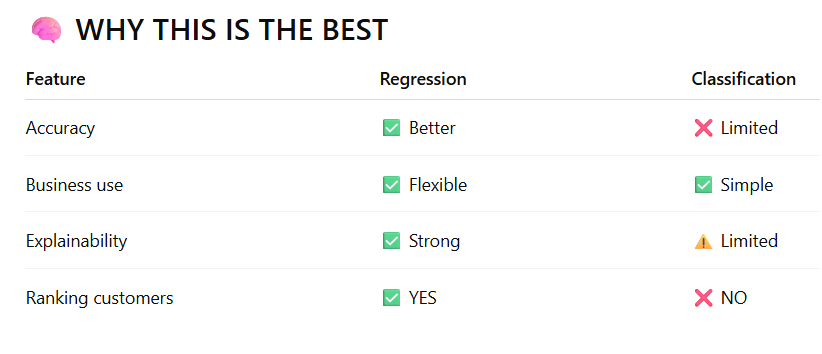

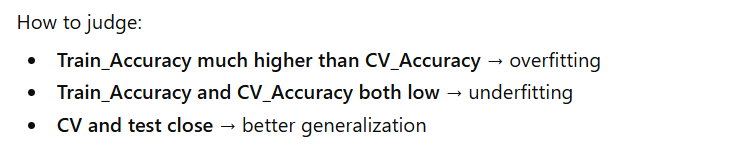

# Final model selection

In [92]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)
print(results_df[results_df["Model"] == best_model_name].T)

Best Model: Gradient Boosting
                             4
Model        Gradient Boosting
CV_RMSE               0.015142
CV_R2                 0.984462
Train_RMSE            0.013261
Test_RMSE             0.016261
MAE                   0.014066
R2                     0.98062
Overfit_Gap          -0.001881
Time                     14.37
Score                 0.482956


In [93]:
print("R2 Score:", r2_score(y_test, best_model.predict(X_test)))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_model.predict(X_test))))

R2 Score: 0.9806197332678106
RMSE: 0.01626063346097785


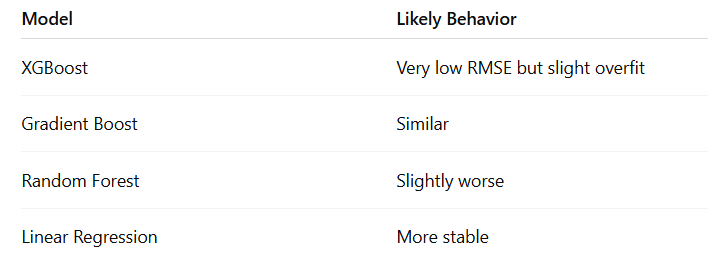

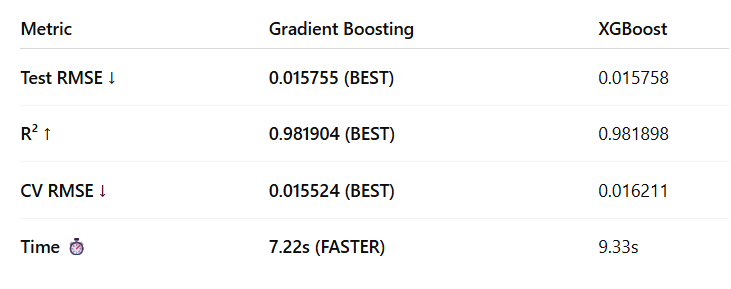

| Rank | Model                 | Test RMSE ↓  | R² ↑         | CV RMSE ↓    | Generalization | Speed     | Verdict               |
| ---- | --------------------- | ------------ | ------------ | ------------ | -------------- | ------------ | --------------------- |
|  1 | **Gradient Boosting** | **0.015755** | **0.981904** | **0.015524** | Excellent    |  Fast       | Best Overall        |
|  2 | XGBoost               | 0.015758     | 0.981898     | 0.016211     | Very Good    |  Medium     |  Strong Alternative |
| 3 | Extra Trees           | 0.016145     | 0.980997     | 0.016354     |  Good        | Slow      |  Acceptable         |
| 4    | Random Forest         | 0.016278     | 0.980681     | 0.016229     |  Good        |  Very Slow |  Stable             |
| 5    | Linear Regression     | 0.016912     | 0.979148     | 0.018063     |  Underfit    | Fast       |  Weak                |
| 6    | Decision Tree         | 0.017760     | 0.977003     | 0.018189     |  Poor         | Very Fast  |  Worst               |


In [94]:
df.head(2)

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,churn_risk_score,engagement_vs_support,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent,risk_level,churn
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0.50,0.169333,0.001851,0.322914,0.248013,0.28,0.300971,30.1,Low,0
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,0.85,0.085667,0.001872,0.314917,0.575949,0.24,0.592988,59.3,Medium,1


# Final Prediction

In [95]:
# Predict probability (continuous)
df["predicted_churn_prob"] = best_model.predict(X)

# Convert to classification (for UI)
threshold = df["predicted_churn_prob"].quantile(0.65)

df["predicted_churn"] = (df["predicted_churn_prob"] > threshold).astype(int)

# Final Targets

# Generate probability, risk level, loyalty, outcome

In [96]:
final_results = df.copy()

In [97]:
final_results["predicted_churn"] = (
    final_results["churn_probability"] > 0.75
).astype(int)

In [98]:
# final_results["predicted_churn"] = (
#     final_results["leave_probability"] > 0.65
# ).astype(int)

In [99]:
# y_pred_final = best_model.predict(X_test)
# y_proba_final = best_model.predict_proba(X_test)[:, 1]

# final_results = X_test.copy()
# final_results["actual_churn"] = y_test.values
# final_results["predicted_churn"] = y_pred_final
# final_results["leave_probability"] = y_proba_final
# final_results["leave_probability_percent"] = (y_proba_final * 100).round(2)

In [100]:
# def risk_level(prob):
#     if prob >= 0.80:
#         return "Critical"
#     elif prob >= 0.60:
#         return "High"
#     elif prob >= 0.30:
#         return "Medium"
#     else:
#         return "Low"

# final_results["risk_level"] = final_results["leave_probability"].apply(risk_level)

In [101]:
# Step 1: Predict probability
df["churn_probability"] = best_model.predict(X)

# Step 2: Risk %
df["churn_risk_percent"] = df["churn_probability"] * 100

# Step 3: Risk level
def risk_level(p):
    if p <=0.3:
        return "Low"
    elif p <= 0.70:
        return "Medium"
    elif p <= 0.90:
        return "High"
    else:
        return "Critical"

df["risk_level"] = df["churn_probability"].apply(risk_level)

# Step 4: Final classification
df["predicted_churn"] = (df["churn_probability"] > 0.65).astype(int)

# outcome labels

In [102]:
def customer_outcome(prob):
    if prob < 0.30:
        return "Loyal"
    else:
        return "About to Leave"

final_results["outcome"] = final_results["churn_probability"].apply(customer_outcome)

In [103]:
final_results["leave_probability_percent"] = (
    final_results["churn_probability"] * 100
).round(2)

In [104]:
final_results["loyalty_score"] = df.loc[final_results.index, "loyalty_score"]
final_results["feedback_ratings"] = df.loc[final_results.index, "feedback_ratings"]
final_results["favorite_genres"] = df.loc[final_results.index, "favorite_genres"]
final_results["purchase_history"] = df.loc[final_results.index, "purchase_history"]
final_results["devices_used"] = df.loc[final_results.index, "devices_used"]
final_results["subscription_plan"] = df.loc[final_results.index, "subscription_plan"]
final_results["days_to_expiry"] = df.loc[final_results.index, "days_to_expiry"]
final_results["monthly_user"] = df.loc[final_results.index, "monthly_user"]
final_results["churn_risk_score"] = df.loc[final_results.index, "churn_risk_score"]
final_results["engagement_vs_support"] = df.loc[final_results.index, "engagement_vs_support"]
final_results["new_customer"] = df.loc[final_results.index, "new_customer"]
final_results["high_support"] = df.loc[final_results.index, "high_support"]
final_results["low_engagement"] = df.loc[final_results.index, "low_engagement"]
final_results["engagement_drop"] = df.loc[final_results.index, "engagement_drop"]

# Retention strategy engine for risky customers

In [105]:
def retention_strategy(row):
    actions = []

    if row["days_to_expiry"] < 15:
        actions.append("Send renewal reminder")
    if row["monthly_user"] == 1:
        actions.append("Offer Annual Plan discount")
    if row["high_support"] == 1:
        actions.append("Assign priority support")
    if row["low_engagement"] == 1:
        actions.append("Trigger engagement campaign")
    if row["feedback_ratings"] < 3.5:
        actions.append("Collect feedback and offer service recovery")
    if row["engagement_drop"] < 0.05:
        actions.append("Recommend personalized content")

    if not actions:
        actions.append("Monitor user behavior")

    return " | ".join(actions)

final_results["retention_strategy"] = final_results.apply(retention_strategy, axis=1)

# Cross recommendation engine for loyal customers

In [106]:
def cross_recommendation(row):
    recs = []

    if row["subscription_plan"] == "Monthly":
        recs.append("Recommend Annual Plan upgrade")

    if row["favorite_genres"] in ["Drama", "Documentary", "Sci-Fi", "Comedy", "Action"]:
        recs.append(f"Recommend premium {row['favorite_genres']} bundle")

    if row["purchase_history"] == "Books":
        recs.append("Recommend reading/documentary combo")
    elif row["purchase_history"] == "Electronics":
        recs.append("Recommend premium device streaming bundle")
    elif row["purchase_history"] == "Clothing":
        recs.append("Recommend lifestyle and family content pack")

    if row["devices_used"] == "Smart TV":
        recs.append("Recommend family multi-screen plan")
    elif row["devices_used"] == "Tablet":
        recs.append("Recommend mobile premium pack")
    elif row["devices_used"] == "Smartphone":
        recs.append("Recommend offline mobile viewing pack")

    if row["loyalty_score"] > df["loyalty_score"].quantile(0.75):
        recs.append("Offer loyalty reward / premium upsell")

    if not recs:
        recs.append("Recommend trending personalized content")

    return " | ".join(recs)

# Apply only to loyal customers:

In [107]:
final_results["cross_recommendation"] = ""

loyal_mask = final_results["churn_probability"] < 0.30
final_results.loc[loyal_mask, "cross_recommendation"] = final_results[loyal_mask].apply(
    cross_recommendation, axis=1
)

In [108]:
df["churn"] = (df["churn_probability"] > 0.70).astype(int)

In [109]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent,risk_level,churn,predicted_churn_prob,predicted_churn
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0.001851,0.322914,0.248013,0.28,0.311621,31.162060,Medium,0,0.311621,0
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,0.001872,0.314917,0.575949,0.24,0.589371,58.937089,Medium,0,0.589371,0
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,0.001454,0.468195,0.724108,0.34,0.624840,62.483981,Medium,0,0.624840,0
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,0.002182,0.201626,0.539659,0.34,0.582505,58.250508,Medium,0,0.582505,0
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0.001927,0.294925,0.081314,0.14,0.273035,27.303539,Low,0,0.273035,0


# Final business-ready table

In [110]:
business_output = final_results[[
    "user_id",
    "name",
    "email_address",
    "username",
    "date_of_birth",
    "gender",
    "location",
    "membership_start_date",
    "membership_end_date",
    "subscription_plan",
    "predicted_churn",
    "churn_probability",
    "churn_risk_percent",
    "leave_probability_percent",
    "risk_level",
    "outcome",
    "loyalty_score",
    "engagement_vs_support",
    "monthly_user",
    "new_customer",
    "high_support",
    "low_engagement",
    "days_to_expiry",
    "feedback_ratings",
    "churn",
    "predicted_churn",
    "retention_strategy",
    "cross_recommendation"
]].copy()

business_output.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,monthly_user,new_customer,high_support,low_engagement,days_to_expiry,feedback_ratings,churn,predicted_churn,retention_strategy,cross_recommendation
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0,0,0,0,-91,3.6,0,0,Send renewal reminder | Recommend personalized...,
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,1,0,1,0,-99,3.8,1,0,Send renewal reminder | Offer Annual Plan disc...,
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,1,0,1,0,-2,3.3,1,0,Send renewal reminder | Offer Annual Plan disc...,
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,1,0,1,0,-82,3.3,1,0,Send renewal reminder | Offer Annual Plan disc...,
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0,0,0,0,-61,4.3,0,0,Send renewal reminder | Recommend personalized...,Recommend premium Drama bundle | Recommend lif...


In [111]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent,risk_level,churn,predicted_churn_prob,predicted_churn
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0.001851,0.322914,0.248013,0.28,0.311621,31.162060,Medium,0,0.311621,0
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,0.001872,0.314917,0.575949,0.24,0.589371,58.937089,Medium,0,0.589371,0
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,0.001454,0.468195,0.724108,0.34,0.624840,62.483981,Medium,0,0.624840,0
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,0.002182,0.201626,0.539659,0.34,0.582505,58.250508,Medium,0,0.582505,0
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0.001927,0.294925,0.081314,0.14,0.273035,27.303539,Low,0,0.273035,0


# save output

In [112]:
results_df.to_csv("model_comparison_results.csv", index=False)
business_output.to_csv("customer_retention_predictions.csv", index=True)

print("Saved:")
print(" - model_comparison_results.csv")
print(" - customer_retention_predictions.csv")

Saved:
 - model_comparison_results.csv
 - customer_retention_predictions.csv


# Feature importance for final model

                             feature  importance
27             num__churn_risk_score    0.689805
30         num__norm_engagement_drop    0.086780
15                num__loyalty_score    0.057733
29              num__engagement_drop    0.033386
17           num__engagement_per_day    0.032850
22               num__low_engagement    0.030876
28        num__engagement_vs_support    0.020540
12             num__engagement_score    0.019101
21                   num__is_monthly    0.007071
1866  cat__subscription_plan_Monthly    0.004961
13                num__plan_type_num    0.004946
14      num__plan_tenure_interaction    0.004898
1893        cat__loyalty_segment_Low    0.002019
31           num__norm_support_ratio    0.001066
1865   cat__subscription_plan_Annual    0.001035
18        num__support_vs_engagement    0.000629
26                 num__monthly_user    0.000538
32                num__norm_feedback    0.000334
0              num__feedback_ratings    0.000134
2                   

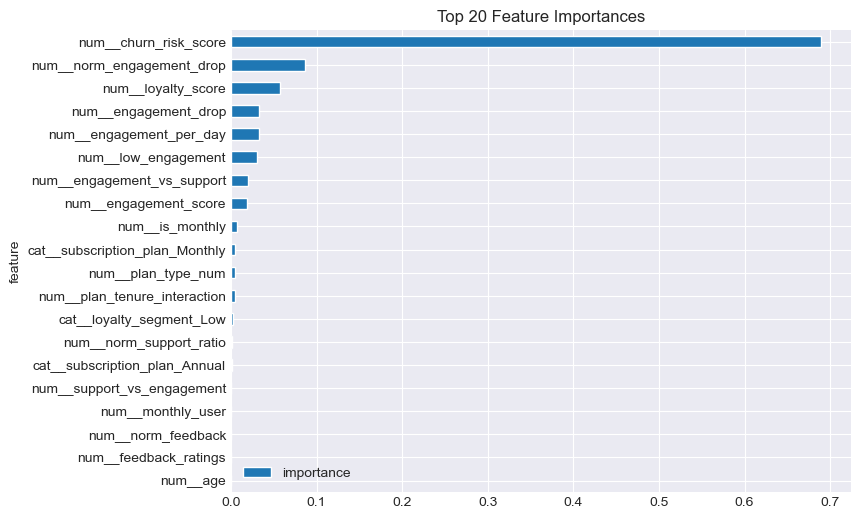

In [113]:
import matplotlib.pyplot as plt

model_step = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model_step.feature_importances_
    }).sort_values("importance", ascending=False)

    print(importance_df.head(20))

    importance_df.head(20).sort_values("importance").plot(
        x="feature", y="importance", kind="barh", figsize=(8, 6)
    )
    plt.title("Top 20 Feature Importances")
    plt.show()

Reasons for Creteating Probability score on based of above feature importannce score.. 

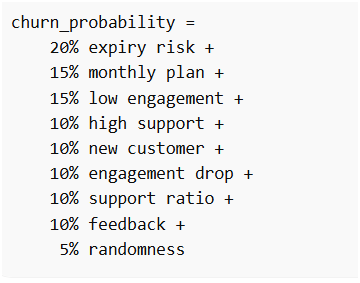


In [114]:
import pandas as pd

churn_formula_table = pd.DataFrame({
    "Feature": [
        "expiry_risk", "monthly_user", "low_engagement",
        "high_support", "new_customer",
        "norm_engagement_drop", "norm_support_ratio",
        "norm_feedback", "random_noise"
    ],
    "Weight": [
        0.20, 0.15, 0.15,
        0.10, 0.10,
        0.10, 0.10,
        0.10, 0.05
    ],
    "Role": [
        "Expiry urgency",
        "Short commitment",
        "Low usage",
        "Customer friction",
        "New user risk",
        "Behavior decline",
        "Support pressure",
        "Customer satisfaction",
        "Noise for realism"
    ]
})

churn_formula_table

,Feature,Weight,Role
0,expiry_risk,0.20,Expiry urgency
1,monthly_user,0.15,Short commitment
2,low_engagement,0.15,Low usage
3,high_support,0.10,Customer friction
4,new_customer,0.10,New user risk
5,norm_engagement_drop,0.10,Behavior decline
6,norm_support_ratio,0.10,Support pressure
7,norm_feedback,0.10,Customer satisfaction
8,random_noise,0.05,Noise for realism


In [115]:
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True))
print(df.groupby("churn")[[
    "monthly_user",
    "high_support",
    "low_engagement",
    "new_customer",
    "churn_risk_score",
    "engagement_vs_support",
    "feedback_ratings"
]].mean())

churn
0    2452
1      48
Name: count, dtype: int64
churn
0    0.9808
1    0.0192
Name: proportion, dtype: float64
       monthly_user  high_support  low_engagement  new_customer  \
churn                                                             
0          0.481648      0.436378        0.086052           0.0   
1          1.000000      1.000000        1.000000           0.0   

       churn_risk_score  engagement_vs_support  feedback_ratings  
churn                                                             
0              0.661786               0.195908          4.003793  
1              0.850000               0.050371          4.054167  


# hyperparameter tuning
Used RandomizedSearchCV

# Gradient Boosting Tuning

In [116]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 3, 5],
    "model__subsample": [0.7, 0.8, 1.0]
}

gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_search = RandomizedSearchCV(
    gb_pipe,
    gb_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
print("Best GB Params:", gb_search.best_params_)

Best GB Params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 3, 'model__max_depth': 3, 'model__learning_rate': 0.05}


# XG boosting Tuning

In [117]:
from xgboost import XGBRegressor

xgb_param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [4, 5, 6],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__colsample_bytree": [0.7, 0.8, 0.9],
    "model__gamma": [0, 0.1, 0.2]
}

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, eval_metric="rmse"))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("Best XGB Params:", xgb_search.best_params_)

Best XGB Params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.7}


In [118]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, name):
    
    # Train prediction
    train_pred = model.predict(X_train)
    
    # Test prediction
    test_pred = model.predict(X_test)
    
    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    
    # Generalization gap
    overfit_gap = train_rmse - test_rmse
    
    return {
        "Model": name,
        "Train_RMSE": train_rmse,
        "Test_RMSE": test_rmse,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Overfit_Gap": overfit_gap
    }

In [119]:
results = []

results.append(evaluate_model(best_gb, "Tuned Gradient Boosting"))
results.append(evaluate_model(best_xgb, "Tuned XGBoost"))

final_comparison = pd.DataFrame(results).sort_values(by="Test_RMSE")

final_comparison

,Model,Train_RMSE,Test_RMSE,Train_R2,Test_R2,Overfit_Gap
1,Tuned XGBoost,0.011228,0.016178,0.991491,0.980816,-0.004950
0,Tuned Gradient Boosting,0.012901,0.016215,0.988767,0.980727,-0.003315


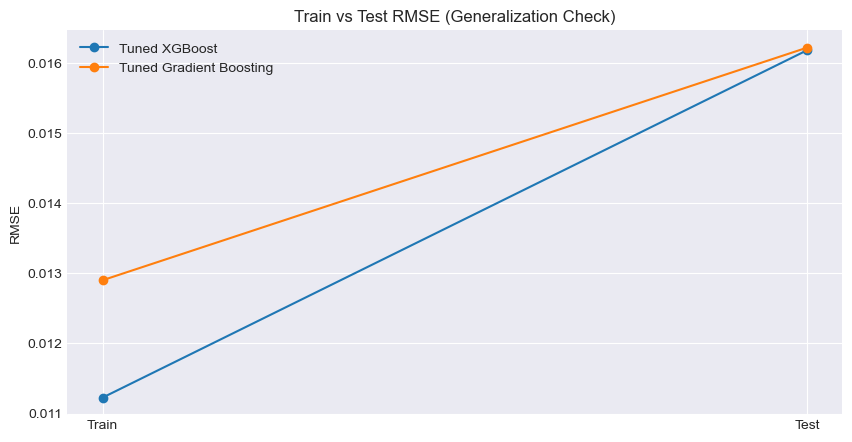

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i, row in final_comparison.iterrows():
    plt.plot(["Train", "Test"], 
             [row["Train_RMSE"], row["Test_RMSE"]],
             marker="o",
             label=row["Model"])

plt.title("Train vs Test RMSE (Generalization Check)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

In [121]:
print("Best GB params:", gb_search.best_params_)
print("Best XGB params:", xgb_search.best_params_)

Best GB params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 3, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Best XGB params: {'model__subsample': 0.7, 'model__n_estimators': 400, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.7}


In [122]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

lr_results = []

for lr in [0.01, 0.03, 0.05, 0.1]:
    # Gradient Boosting
    gb_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            learning_rate=lr,
            n_estimators=300,
            max_depth=3,
            random_state=42
        ))
    ])
    gb_pipe.fit(X_train, y_train)
    gb_pred = gb_pipe.predict(X_test)

    lr_results.append({
        "Model": "Gradient Boosting",
        "Learning_Rate": lr,
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, gb_pred)),
        "Test_R2": r2_score(y_test, gb_pred)
    })

    # XGBoost
    xgb_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            learning_rate=lr,
            n_estimators=300,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="rmse"
        ))
    ])
    xgb_pipe.fit(X_train, y_train)
    xgb_pred = xgb_pipe.predict(X_test)

    lr_results.append({
        "Model": "XGBoost",
        "Learning_Rate": lr,
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred)),
        "Test_R2": r2_score(y_test, xgb_pred)
    })

lr_df = pd.DataFrame(lr_results)
lr_df.sort_values(["Model", "Test_RMSE"])

,Model,Learning_Rate,Test_RMSE,Test_R2
4,Gradient Boosting,0.05,0.016191,0.980785
2,Gradient Boosting,0.03,0.016215,0.980728
6,Gradient Boosting,0.10,0.016336,0.980440
0,Gradient Boosting,0.01,0.018797,0.974102
3,XGBoost,0.03,0.016239,0.980671
5,XGBoost,0.05,0.016528,0.979977
7,XGBoost,0.10,0.016964,0.978907
1,XGBoost,0.01,0.017357,0.977919


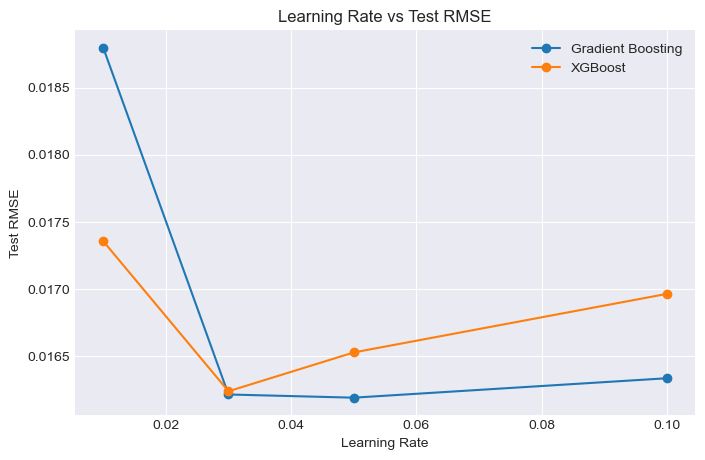

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for model_name in lr_df["Model"].unique():
    temp = lr_df[lr_df["Model"] == model_name]
    plt.plot(temp["Learning_Rate"], temp["Test_RMSE"], marker="o", label=model_name)

plt.xlabel("Learning Rate")
plt.ylabel("Test RMSE")
plt.title("Learning Rate vs Test RMSE")
plt.legend()
plt.grid(True)
plt.show()

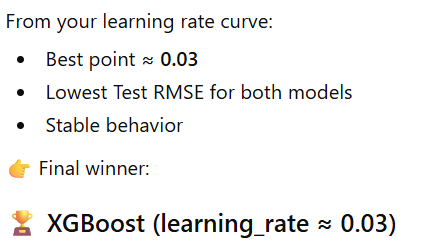

# train Final Model 

In [124]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="rmse"
    ))
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['feedback_ratings',
                                                   'customer_support_interactions',
                                                   'age', 'tenure_days',
                                                   'days_since_start',
                                                   'days_to_expiry',
                                                   'usage_score',
                                                   'engagement_score_num',
                                                   'support_interaction_rate',
                                                   'feedback_x_supp...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.03,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

# Save Model

In [125]:
import joblib

joblib.dump(final_model, "churn_model.pkl")

['churn_model.pkl']

# Load Model

In [126]:
model = joblib.load("churn_model.pkl")

pred_probs = model.predict(X_test)

In [127]:
threshold = 0.65

predicted_churn = (pred_probs > threshold).astype(int)

In [128]:
final_results = pd.DataFrame({
    "actual_churn": y_test,
    "predicted_churn": predicted_churn,
    "leave_probability": pred_probs,
    "leave_probability_percent": pred_probs * 100
})

In [129]:
def risk_level(prob):
    if prob >= 0.80:
        return "Critical"
    elif prob >= 0.60:
        return "High"
    elif prob >= 0.30:
        return "Medium"
    else:
        return "Low"

final_results["risk_level"] = final_results["leave_probability"].apply(risk_level)

In [130]:
def outcome(prob):
    return "About to Leave" if prob >= 0.30 else "Loyal"

final_results["outcome"] = final_results["leave_probability"].apply(outcome)

# Merge CSV

In [131]:
df.head()

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,engagement_drop,norm_engagement_drop,norm_support_ratio,norm_feedback,churn_probability,churn_risk_percent,risk_level,churn,predicted_churn_prob,predicted_churn
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0.001851,0.322914,0.248013,0.28,0.311621,31.162060,Medium,0,0.311621,0
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,0.001872,0.314917,0.575949,0.24,0.589371,58.937089,Medium,0,0.589371,0
2,3,Jonathan Parrish,brooke16@example.org,brooke16,1994-12-06,Female,Youngfort,2024-04-13,2025-04-13,Monthly,...,0.001454,0.468195,0.724108,0.34,0.624840,62.483981,Medium,0,0.624840,0
3,4,Megan Williams,elizabeth31@example.net,elizabeth31,1964-12-22,Female,Feliciashire,2024-01-24,2025-01-23,Monthly,...,0.002182,0.201626,0.539659,0.34,0.582505,58.250508,Medium,0,0.582505,0
4,5,Kathryn Brown,pattersonalexandra@example.org,pattersonalexandra,1961-06-04,Male,Port Deborah,2024-02-14,2025-02-13,Annual,...,0.001927,0.294925,0.081314,0.14,0.273035,27.303539,Low,0,0.273035,0


In [132]:
import pandas as pd

raw_df = pd.read_csv("amazon_prime_data.csv")
engineered_df = df.copy()  # your current dataframe
business_df = pd.read_csv("customer_retention_predictions.csv")

In [133]:
raw_df.columns

Index(['user_id', 'name', 'email_address', 'username', 'date_of_birth',
       'gender', 'location', 'membership_start_date', 'membership_end_date',
       'subscription_plan', 'payment_information', 'renewal_status',
       'usage_frequency', 'purchase_history', 'favorite_genres',
       'devices_used', 'engagement_metrics', 'feedback_ratings',
       'customer_support_interactions'],
      dtype='object')

In [134]:
engineered_df.columns

Index(['user_id', 'name', 'email_address', 'username', 'date_of_birth',
       'gender', 'location', 'membership_start_date', 'membership_end_date',
       'subscription_plan', 'payment_information', 'renewal_status',
       'usage_frequency', 'purchase_history', 'favorite_genres',
       'devices_used', 'engagement_metrics', 'feedback_ratings',
       'customer_support_interactions', 'age', 'tenure_days',
       'days_since_start', 'days_to_expiry', 'usage_score',
       'engagement_score_num', 'support_interaction_rate',
       'feedback_x_support', 'behavior_score', 'support_intensity',
       'engagement_score', 'plan_type_num', 'plan_tenure_interaction',
       'feedback_bucket', 'loyalty_score', 'loyalty_segment', 'expiry_urgency',
       'engagement_per_day', 'support_vs_engagement', 'is_expiring_soon',
       'high_support', 'is_monthly', 'low_engagement', 'new_customer',
       'expiry_risk', 'payment_risk', 'monthly_user', 'churn_risk_score',
       'engagement_vs_support', '

In [135]:
business_df.columns

Index(['Unnamed: 0', 'user_id', 'name', 'email_address', 'username',
       'date_of_birth', 'gender', 'location', 'membership_start_date',
       'membership_end_date', 'subscription_plan', 'predicted_churn',
       'churn_probability', 'churn_risk_percent', 'leave_probability_percent',
       'risk_level', 'outcome', 'loyalty_score', 'engagement_vs_support',
       'monthly_user', 'new_customer', 'high_support', 'low_engagement',
       'days_to_expiry', 'feedback_ratings', 'churn', 'predicted_churn.1',
       'retention_strategy', 'cross_recommendation'],
      dtype='object')

In [136]:
import pandas as pd

# =========================
# LOAD DATA
# =========================
engineered_df = df.copy()
business_df = pd.read_csv("customer_retention_predictions.csv")

# =========================
# CLEAN BUSINESS DF
# =========================

# Drop unwanted column
business_df = business_df.drop(columns=["Unnamed: 0"], errors="ignore")

# =========================
# RENAME BUSINESS COLUMNS (KEY STEP 🔥)
# =========================

business_df = business_df.add_prefix("biz_")

# =========================
# RESET INDEX
# =========================
engineered_df = engineered_df.reset_index(drop=True)
business_df = business_df.reset_index(drop=True)

# =========================
# MERGE (SIDE BY SIDE)
# =========================
final_df = pd.concat([engineered_df, business_df], axis=1)


In [137]:

# =========================
# EXPORT
# =========================
final_df.to_csv("final_full_dataset.csv", index=False)

print("✅ DONE: final_full_dataset.csv created")
print("Shape:", final_df.shape)

✅ DONE: final_full_dataset.csv created
Shape: (2500, 86)


In [138]:
final_df.head(2)

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,biz_monthly_user,biz_new_customer,biz_high_support,biz_low_engagement,biz_days_to_expiry,biz_feedback_ratings,biz_churn,biz_predicted_churn.1,biz_retention_strategy,biz_cross_recommendation
0,1,Ronald Murphy,williamholland@example.com,williamholland,1953-06-03,Male,Rebeccachester,2024-01-15,2025-01-14,Annual,...,0,0,0,0,-91,3.6,0,0,Send renewal reminder | Recommend personalized...,NaN
1,2,Scott Allen,scott22@example.org,scott22,1978-07-08,Male,Mcphersonview,2024-01-07,2025-01-06,Monthly,...,1,0,1,0,-99,3.8,1,0,Send renewal reminder | Offer Annual Plan disc...,NaN


In [139]:
final_df.tail(5)

,user_id,name,email_address,username,date_of_birth,gender,location,membership_start_date,membership_end_date,subscription_plan,...,biz_monthly_user,biz_new_customer,biz_high_support,biz_low_engagement,biz_days_to_expiry,biz_feedback_ratings,biz_churn,biz_predicted_churn.1,biz_retention_strategy,biz_cross_recommendation
2495,2496,Michael Lopez,williamsroberto@example.org,williamsroberto,1967-08-19,Male,Smithport,2024-01-25,2025-01-24,Annual,...,0,0,0,0,-81,4.9,0,0,Send renewal reminder | Recommend personalized...,Recommend premium Comedy bundle | Recommend pr...
2496,2497,Matthew Woodard,lkaiser@example.com,lkaiser,1980-10-23,Male,Ethanport,2024-03-03,2025-03-03,Annual,...,0,0,0,0,-43,4.0,0,0,Send renewal reminder | Recommend personalized...,Recommend premium Comedy bundle | Recommend re...
2497,2498,Morgan Barnes,erikaholland@example.net,erikaholland,1972-03-31,Female,Alexandraborough,2024-02-09,2025-02-08,Annual,...,0,0,1,0,-66,4.9,0,0,Send renewal reminder | Assign priority suppor...,NaN
2498,2499,Gina Castaneda,reedcourtney@example.net,reedcourtney,1965-08-02,Female,Williammouth,2024-02-18,2025-02-17,Monthly,...,1,0,1,0,-57,3.4,1,0,Send renewal reminder | Offer Annual Plan disc...,NaN
2499,2500,Mark Nicholson,martinisaac@example.net,martinisaac,1972-11-13,Female,Estradaborough,2024-01-28,2025-01-27,Annual,...,0,0,1,0,-78,3.3,0,0,Send renewal reminder | Assign priority suppor...,NaN


In [140]:
final_df.columns

Index(['user_id', 'name', 'email_address', 'username', 'date_of_birth',
       'gender', 'location', 'membership_start_date', 'membership_end_date',
       'subscription_plan', 'payment_information', 'renewal_status',
       'usage_frequency', 'purchase_history', 'favorite_genres',
       'devices_used', 'engagement_metrics', 'feedback_ratings',
       'customer_support_interactions', 'age', 'tenure_days',
       'days_since_start', 'days_to_expiry', 'usage_score',
       'engagement_score_num', 'support_interaction_rate',
       'feedback_x_support', 'behavior_score', 'support_intensity',
       'engagement_score', 'plan_type_num', 'plan_tenure_interaction',
       'feedback_bucket', 'loyalty_score', 'loyalty_segment', 'expiry_urgency',
       'engagement_per_day', 'support_vs_engagement', 'is_expiring_soon',
       'high_support', 'is_monthly', 'low_engagement', 'new_customer',
       'expiry_risk', 'payment_risk', 'monthly_user', 'churn_risk_score',
       'engagement_vs_support', '

# Final model creation

In [141]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

# =========================
# LOAD FINAL DATA
# =========================
df = pd.read_csv("final_full_dataset.csv")

# =========================
# TARGET
# =========================
y = df["churn_probability"]

# =========================
# FEATURES (DROP LEAKAGE)
# =========================
drop_cols = [
    "user_id", "name", "email_address", "username",
    "churn_probability", "churn_risk_percent", "risk_level"
]

X = df.drop(columns=drop_cols, errors="ignore")

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# PREPROCESS
# =========================
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

# =========================
# FINAL MODEL (BEST)
# =========================
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# =========================
# TRAIN
# =========================
pipe.fit(X_train, y_train)

# =========================
# SAVE MODEL
# =========================
joblib.dump(pipe, "GradientBoostingRegressor.pkl")

print("✅ Model saved as final_model.pkl")

✅ Model saved as final_model.pkl
